**Import Libraries**

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

import pickle

In [3]:
from google.colab import files
uploaded = files.upload()

Saving kc_house_data.csv to kc_house_data.csv


**Data Collection**

In [4]:
df = pd.read_csv("kc_house_data.csv")

df.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


**Data Cleaning**

In [5]:
df = df.drop(['id', 'date'], axis=1)

df = df.dropna()

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 19 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   price          21613 non-null  float64
 1   bedrooms       21613 non-null  int64  
 2   bathrooms      21613 non-null  float64
 3   sqft_living    21613 non-null  int64  
 4   sqft_lot       21613 non-null  int64  
 5   floors         21613 non-null  float64
 6   waterfront     21613 non-null  int64  
 7   view           21613 non-null  int64  
 8   condition      21613 non-null  int64  
 9   grade          21613 non-null  int64  
 10  sqft_above     21613 non-null  int64  
 11  sqft_basement  21613 non-null  int64  
 12  yr_built       21613 non-null  int64  
 13  yr_renovated   21613 non-null  int64  
 14  zipcode        21613 non-null  int64  
 15  lat            21613 non-null  float64
 16  long           21613 non-null  float64
 17  sqft_living15  21613 non-null  int64  
 18  sqft_l

**Exploratory Data Analysis (EDA)**

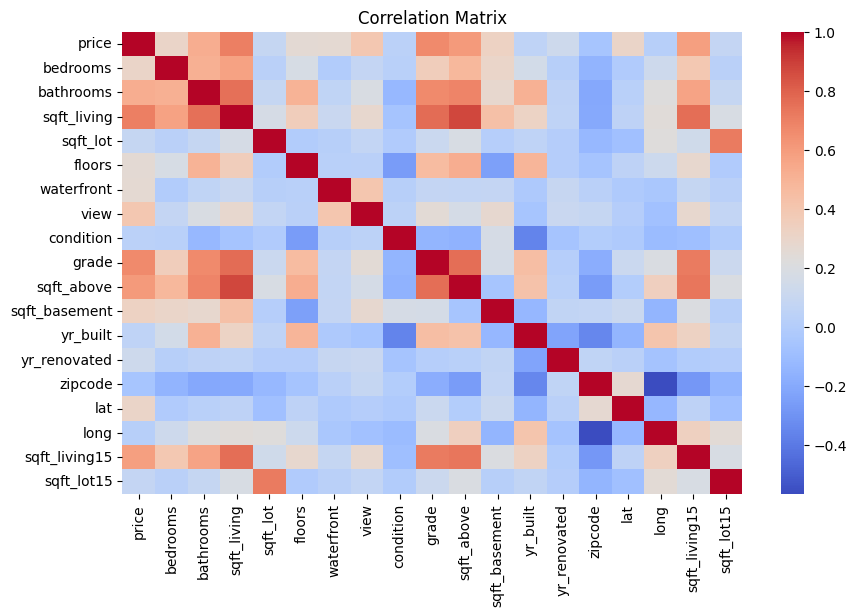

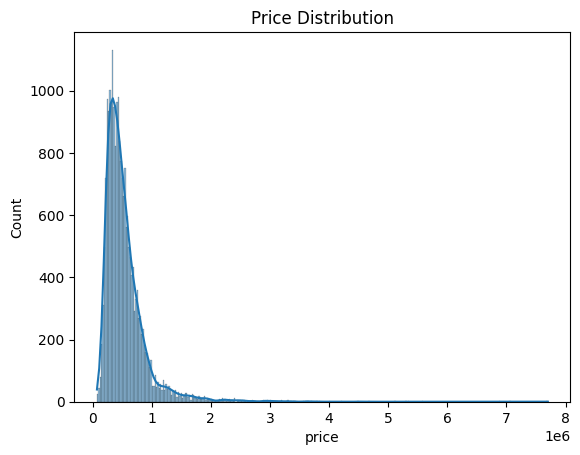

In [6]:
# Correlation heatmap
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

# Price distribution
sns.histplot(df['price'], kde=True)
plt.title("Price Distribution")
plt.show()

Top Features vs Price

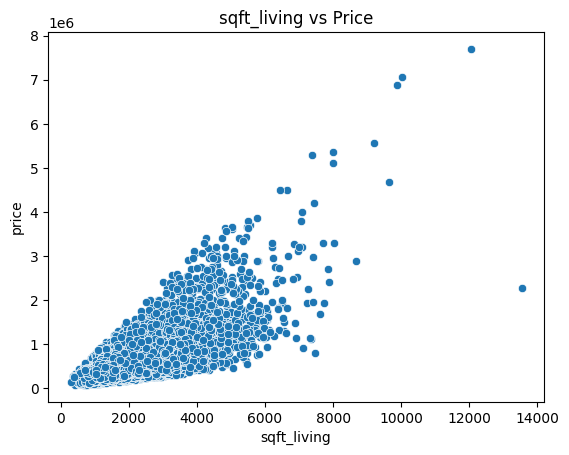

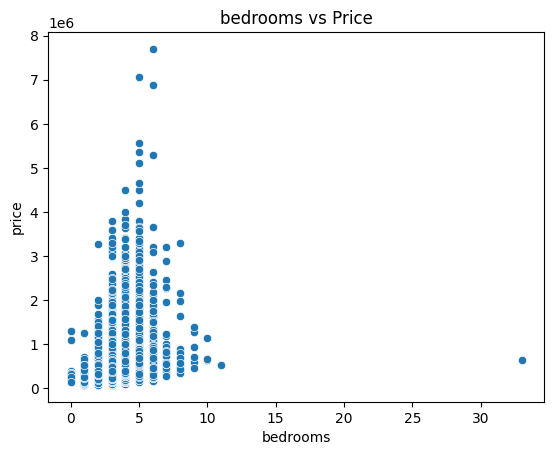

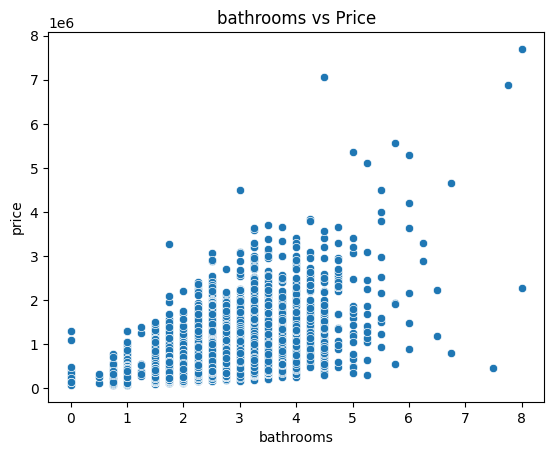

In [22]:
features = ['sqft_living', 'bedrooms', 'bathrooms']

for feature in features:
    plt.figure()
    sns.scatterplot(x=df[feature], y=df['price'])
    plt.title(f"{feature} vs Price")
    plt.show()

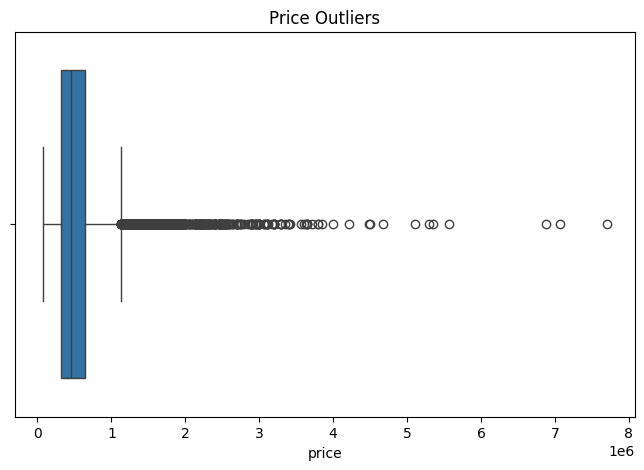

In [23]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df['price'])
plt.title("Price Outliers")
plt.show()

Bedrooms vs Price

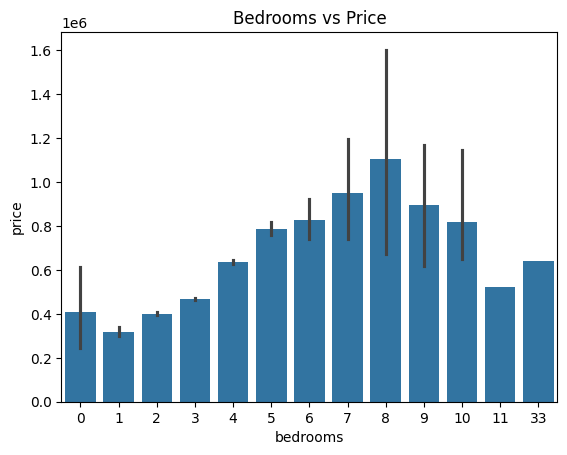

In [25]:
sns.barplot(x='bedrooms', y='price', data=df)
plt.title("Bedrooms vs Price")
plt.show()

Bathrooms vs Price

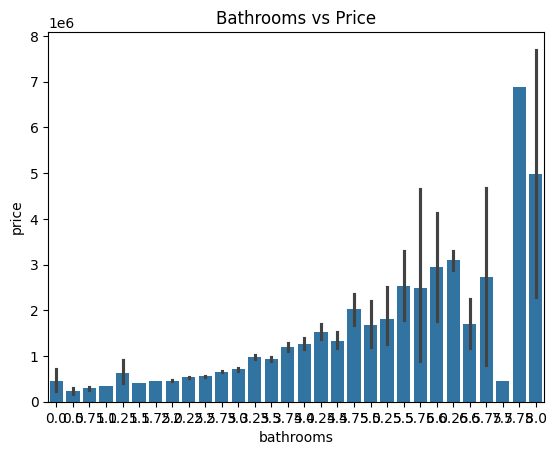

In [26]:
sns.barplot(x='bathrooms', y='price', data=df)
plt.title("Bathrooms vs Price")
plt.show()

**Feature Selection**

In [7]:
# Features & Target
X = df.drop('price', axis=1)
y = df['price']

**Train-Test Split**

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

**Model Building**

In [11]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

**Model Evaluation**

In [12]:
y_pred = model.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

MAE: 127493.34208656367
R2 Score: 0.7011904448878442


**Save Model**

In [13]:
with open('model.pkl', 'wb') as f:
    pickle.dump(model, f)

Download model:

In [14]:
from google.colab import files
files.download('model.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

**Deployment using Streamlit**

In [16]:
!pip install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 64.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 108.6 MB/s eta 0:00:00


In [20]:
%%writefile app.py

import streamlit as st
import numpy as np
import pickle

model = pickle.load(open('model.pkl', 'rb'))

st.title("House Price Prediction")

bedrooms = st.number_input("Bedrooms", 1, 10)
bathrooms = st.number_input("Bathrooms", 1, 10)
sqft_living = st.number_input("Sqft Living")
floors = st.number_input("Floors", 1, 5)

if st.button("Predict"):
    features = np.array([[bedrooms, bathrooms, sqft_living, floors]])
    result = model.predict(features)
    st.write("Predicted Price:", result[0])

Overwriting app.py


In [21]:
from google.colab import files
files.download('app.py')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>